<a href="https://colab.research.google.com/github/Gaurav-Rawool/Machin-learning/blob/main/Gaurav_ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


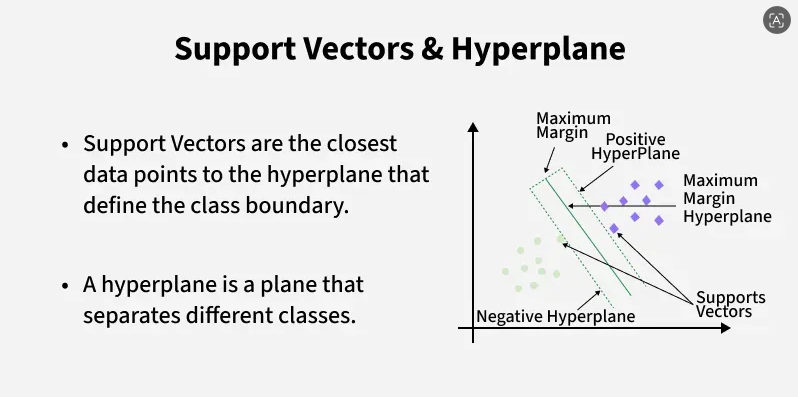
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

Gaurav Rawool, CE-39, Batch- CE3

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [2]:
# Task 1: Import Libraries and Upload Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Upload dataset
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the uploaded CSV file
df = pd.read_csv(file_name)

# Display first 5 rows
print("Dataset loaded successfully!")
print("\nFirst five rows of the dataset:")
print(df.head())

Saving Iris (1).csv to Iris (1).csv
Dataset loaded successfully!

First five rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Task 2: Explore the Dataset

In [3]:
# Task 2: Explore the Dataset

# Display dataset shape
print("Shape of the dataset:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display basic information
print("\nDataset information:")
df.info()

# Display statistical summary
print("\nStatistical summary:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Display class distribution
print("\nClass distribution:")
print(df["Species"].value_counts())

Shape of the dataset:
(150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min 

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [4]:
# Task 3: Select Features and Target

# Remove the Id column
df_model = df.drop(columns=["Id"])

# Select input features
X = df_model.drop(columns=["Species"])

# Select target variable
y = df_model["Species"]

# Display the selected features
print("Selected Features:")
print(X.head())

# Display target variable
print("\nTarget Variable:")
print(y.head())

# Display feature names
print("\nFeature Names:")
print(X.columns.tolist())

# Display target classes
print("\nTarget Classes:")
print(y.unique())

Selected Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target Variable:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Feature Names:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [5]:
# Task 4: Split and Scale the Data

# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display the sizes
print("Training data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

print("\nTraining target shape:")
print(y_train.shape)

print("\nTesting target shape:")
print(y_test.shape)

# Display first 5 rows of scaled training data
print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled[:5])

Training data shape:
(120, 4)

Testing data shape:
(30, 4)

Training target shape:
(120,)

Testing target shape:
(30,)

First 5 rows of scaled training data:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [6]:
# Task 5: Implement Linear SVM

from sklearn.svm import SVC

# Create Linear SVM model
svm_model = SVC(
    kernel="linear",
    C=1.0
)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Display predictions
print("SVM Predictions:")
print(y_pred_svm)

# Display actual values
print("\nActual Values:")
print(y_test.values)

# Display support vectors
print("\nNumber of support vectors for each class:")
print(svm_model.n_support_)

print("\nTotal number of support vectors:")
print(len(svm_model.support_))

SVM Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']

Actual Values:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 '

# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [7]:
# Task 6: Evaluate Linear SVM

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:")
print(accuracy_svm)

print("\nSVM Accuracy in Percentage:")
print("{:.2f}%".format(accuracy_svm * 100))


# Generate confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm_svm)


# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy:
1.0

SVM Accuracy in Percentage:
100.00%

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

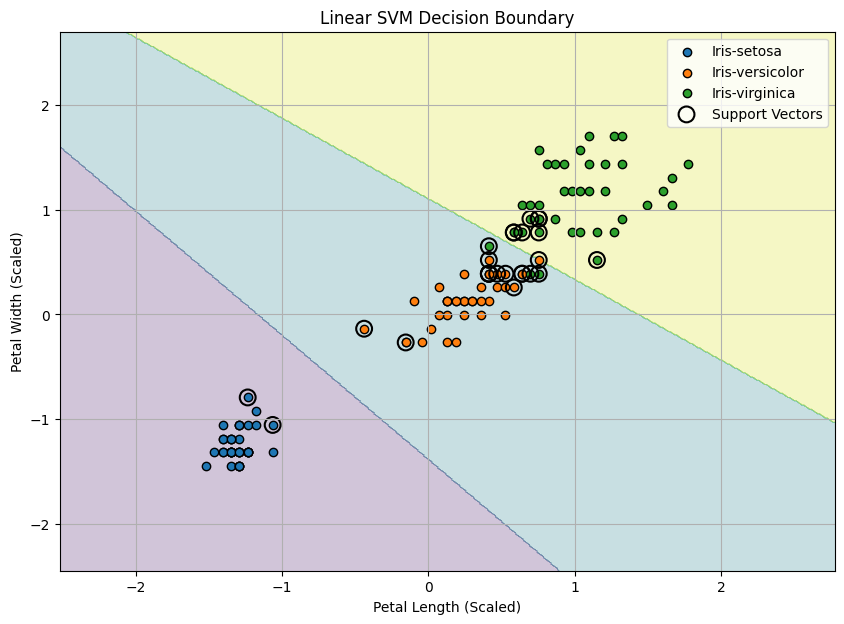

Number of support vectors for each class:
[ 2 13 10]

Total number of support vectors:
25


In [8]:
# Task 7: Visualize Linear SVM Decision Boundary

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Select Petal Length and Petal Width
X_2D = df[["PetalLengthCm", "PetalWidthCm"]]
y_2D = df["Species"]

# Split the 2-D dataset
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2D,
    y_2D,
    test_size=0.20,
    random_state=42,
    stratify=y_2D
)

# Scale the data
scaler_2D = StandardScaler()

X2_train_scaled = scaler_2D.fit_transform(X2_train)
X2_test_scaled = scaler_2D.transform(X2_test)

# Train Linear SVM
svm_2D = SVC(
    kernel="linear",
    C=1.0
)

svm_2D.fit(X2_train_scaled, y2_train)

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict classes for every point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_2D.predict(grid_points)

# Convert class labels to numbers
class_names = svm_2D.classes_

Z_numeric = np.array([
    np.where(class_names == value)[0][0]
    for value in Z
])

Z_numeric = Z_numeric.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25
)

# Plot training data
for class_name in class_names:

    mask = y2_train == class_name

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=class_name,
        edgecolor="black"
    )

# Highlight support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=130,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

# Display number of support vectors
print("Number of support vectors for each class:")
print(svm_2D.n_support_)

print("\nTotal number of support vectors:")
print(len(svm_2D.support_vectors_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

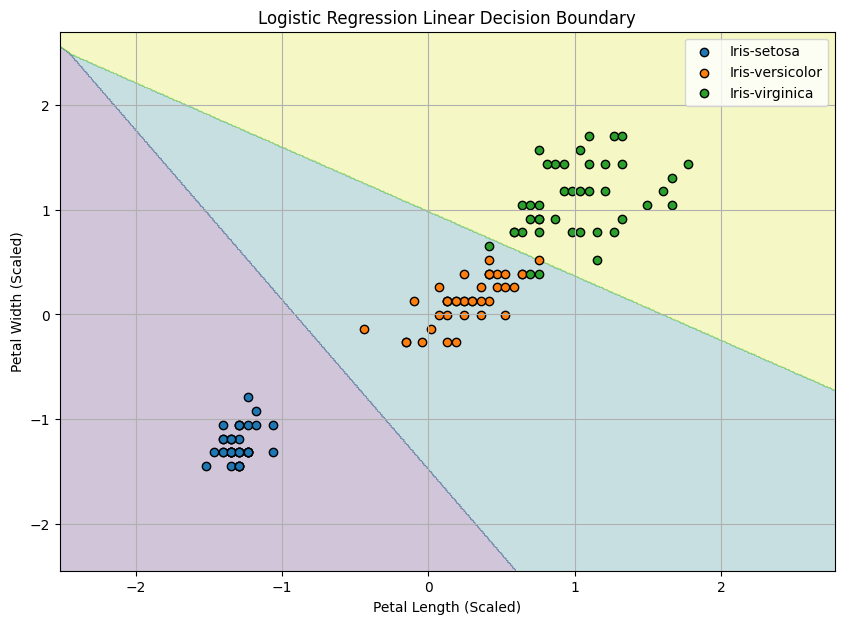

In [9]:
# Task 8: Normal Linear Classification Boundary
# Using Logistic Regression

from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000
)

# Train Logistic Regression
logistic_model.fit(
    X2_train_scaled,
    y2_train
)

# Make predictions
y_pred_logistic = logistic_model.predict(X2_test_scaled)

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict classes for mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = logistic_model.predict(grid_points)

# Convert class labels to numbers
class_names = logistic_model.classes_

Z_numeric = np.array([
    np.where(class_names == value)[0][0]
    for value in Z
])

Z_numeric = Z_numeric.reshape(xx.shape)

# Plot Logistic Regression decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25
)

# Plot training data
for class_name in class_names:

    mask = y2_train == class_name

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=class_name,
        edgecolor="black"
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Linear Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

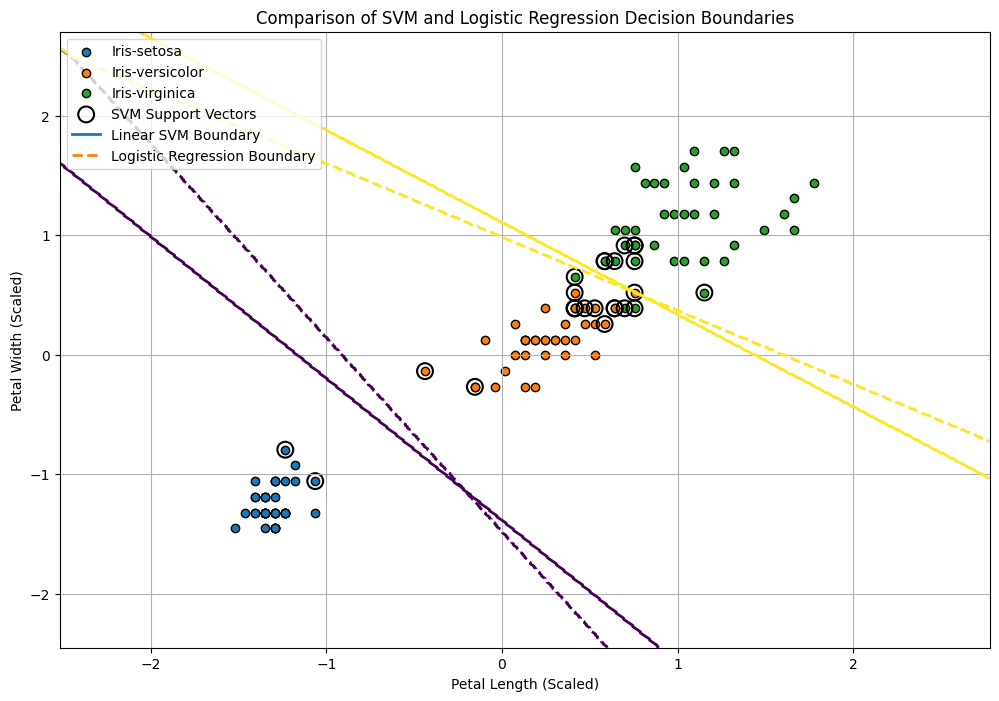

In [10]:
# Task 9: Compare SVM and Logistic Regression Boundaries

import numpy as np
import matplotlib.pyplot as plt

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Points in the mesh
grid_points = np.c_[xx.ravel(), yy.ravel()]

# SVM predictions
Z_svm = svm_2D.predict(grid_points)

# Logistic Regression predictions
Z_logistic = logistic_model.predict(grid_points)

# Convert class labels to numerical values
class_names = svm_2D.classes_

Z_svm_numeric = np.array([
    np.where(class_names == value)[0][0]
    for value in Z_svm
])

Z_logistic_numeric = np.array([
    np.where(class_names == value)[0][0]
    for value in Z_logistic
])

Z_svm_numeric = Z_svm_numeric.reshape(xx.shape)
Z_logistic_numeric = Z_logistic_numeric.reshape(xx.shape)

# Create the comparison plot
plt.figure(figsize=(12, 8))

# SVM decision boundaries - solid lines
plt.contour(
    xx,
    yy,
    Z_svm_numeric,
    levels=[0.5, 1.5],
    linewidths=2,
    linestyles="solid"
)

# Logistic Regression boundaries - dashed lines
plt.contour(
    xx,
    yy,
    Z_logistic_numeric,
    levels=[0.5, 1.5],
    linewidths=2,
    linestyles="dashed"
)

# Plot training data
for class_name in class_names:

    mask = y2_train == class_name

    plt.scatter(
        X2_train_scaled[mask, 0],
        X2_train_scaled[mask, 1],
        label=class_name,
        edgecolor="black"
    )

# Highlight SVM support vectors
plt.scatter(
    svm_2D.support_vectors_[:, 0],
    svm_2D.support_vectors_[:, 1],
    s=130,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="SVM Support Vectors"
)

# Legend lines
plt.plot(
    [],
    [],
    linestyle="solid",
    linewidth=2,
    label="Linear SVM Boundary"
)

plt.plot(
    [],
    [],
    linestyle="dashed",
    linewidth=2,
    label="Logistic Regression Boundary"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Comparison of SVM and Logistic Regression Decision Boundaries")
plt.legend()
plt.grid(True)

plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [11]:
# Task 10: Compare Performance of SVM and Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# -------------------------------
# SVM Predictions
# -------------------------------

y_pred_svm_2D = svm_2D.predict(X2_test_scaled)

# SVM Accuracy
svm_accuracy = accuracy_score(
    y2_test,
    y_pred_svm_2D
)

# SVM Confusion Matrix
svm_cm = confusion_matrix(
    y2_test,
    y_pred_svm_2D,
    labels=class_names
)

# -------------------------------
# Logistic Regression Predictions
# -------------------------------

y_pred_logistic = logistic_model.predict(
    X2_test_scaled
)

# Logistic Regression Accuracy
logistic_accuracy = accuracy_score(
    y2_test,
    y_pred_logistic
)

# Logistic Regression Confusion Matrix
logistic_cm = confusion_matrix(
    y2_test,
    y_pred_logistic,
    labels=class_names
)

# -------------------------------
# Display Accuracy
# -------------------------------

print("========================================")
print("ACCURACY COMPARISON")
print("========================================")

print("Linear SVM Accuracy:")
print("{:.2f}%".format(svm_accuracy * 100))

print("\nLogistic Regression Accuracy:")
print("{:.2f}%".format(logistic_accuracy * 100))


# -------------------------------
# SVM Confusion Matrix
# -------------------------------

print("\n========================================")
print("LINEAR SVM CONFUSION MATRIX")
print("========================================")

print(svm_cm)


# -------------------------------
# Logistic Regression Confusion Matrix
# -------------------------------

print("\n========================================")
print("LOGISTIC REGRESSION CONFUSION MATRIX")
print("========================================")

print(logistic_cm)


# -------------------------------
# SVM Classification Report
# -------------------------------

print("\n========================================")
print("LINEAR SVM CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y2_test,
        y_pred_svm_2D
    )
)


# -------------------------------
# Logistic Regression Report
# -------------------------------

print("\n========================================")
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y2_test,
        y_pred_logistic
    )
)

ACCURACY COMPARISON
Linear SVM Accuracy:
93.33%

Logistic Regression Accuracy:
93.33%

LINEAR SVM CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

LOGISTIC REGRESSION CONFUSION MATRIX
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

LINEAR SVM CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


LOGISTIC REGRESSION CLASSIFICATION REPORT
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      m

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.